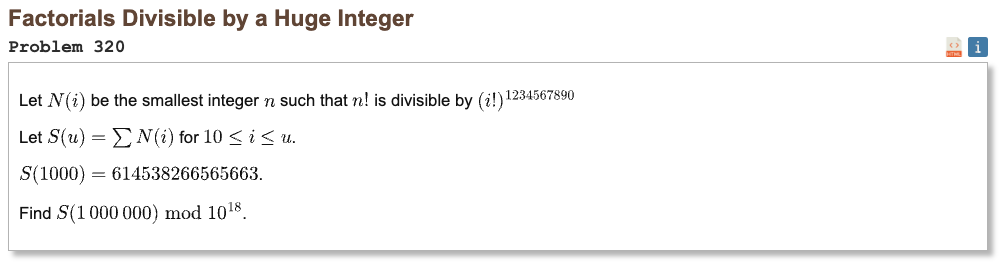

## Initial approach

* keep the prime factor counts of each factorial as i grows
* each new i only changes the primes that divide i
* multiply each needed prime count by the huge exponent
* for each changed prime, binary search the smallest factorial index that contains enough of that prime
* the answer for one i is the largest required index among all primes
* this largest value never decreases as i grows
* sum those values modulo the required large modulus

In [1]:
def sieve_spf(limit):
    spf = list(range(limit + 1))

    for i in range(2, int(limit ** 0.5) + 1):
        if spf[i] == i:
            for j in range(i * i, limit + 1, i):
                if spf[j] == j:
                    spf[j] = i

    return spf

def factorial_prime_power(n, p):
    total = 0

    while n:
        n //= p
        total += n

    return total

def smallest_factorial_index(p, target, low):
    high = max(low + 1, (p - 1) * target + 1)

    while factorial_prime_power(high, p) < target:
        high *= 2

    while low < high:
        mid = (low + high) // 2

        if factorial_prime_power(mid, p) >= target:
            high = mid
        else:
            low = mid + 1

    return low

def solve(limit):
    power = 1234567890
    mod = 10 ** 18

    spf = sieve_spf(limit)
    prime_powers = {}
    prime_required_indices = {}

    current_value = 0
    total = 0

    for i in range(2, limit + 1):
        x = i

        while x > 1:
            p = spf[x]
            count = 0

            while x % p == 0:
                x //= p
                count += 1

            prime_powers[p] = prime_powers.get(p, 0) + count
            target = prime_powers[p] * power

            previous = prime_required_indices.get(p, 0)
            required_index = smallest_factorial_index(p, target, previous)

            prime_required_indices[p] = required_index

            if required_index > current_value:
                current_value = required_index

        if i >= 10:
            total = (total + current_value) % mod

    return total

assert solve(1000) == 614538266565663

In [2]:
%%time
result = solve(1_000_000)
print("Result:", result)

Result: 278157919195482643
CPU times: user 2min, sys: 441 ms, total: 2min
Wall time: 2min 1s
